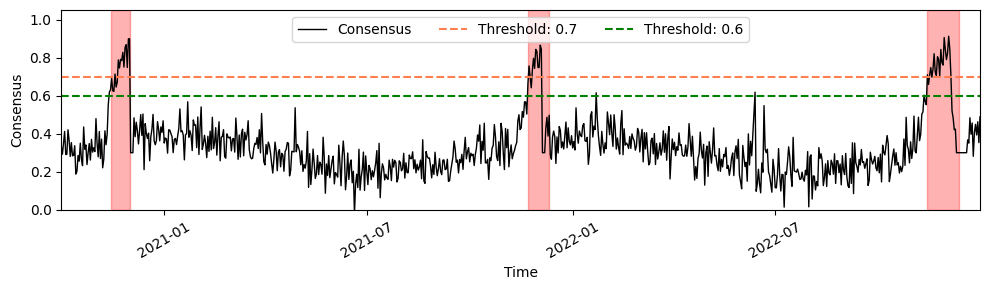

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pandas as pd

# Extended time range to end of 2022
start_date = datetime(2020, 10, 1)   # Start of data
end_date = datetime(2022, 12, 31)    # Extended end date
# dates = pd.date_range(start=start_date, end=end_date, freq='48h')  # Daily frequency
dates = pd.date_range(start=start_date, end=end_date, freq='24h')  # Daily frequency

# Generate synthetic data
np.random.seed(42)  # For reproducibility
n = len(dates)

# Generate baseline consensus data
base = 0.3
consensus = np.zeros(n)
for i in range(n):
    # Base level with noise and some long-term variations
    phase = i / 60  # Slower oscillation
    consensus[i] = base + 0.1 * np.sin(phase) + 0.07 * np.random.randn()

# Define eruption periods
eruption1_start = datetime(2020, 11, 14)
eruption1_end = datetime(2020, 12, 1)
eruption2_start = datetime(2021, 11, 22)
eruption2_end = datetime(2021, 12, 4)
eruption2_end_ = datetime(2021, 12, 11)
eruption3_start = datetime(2022, 11, 14)
eruption3_end = datetime(2022, 12, 4)
eruption3_end_ = datetime(2022, 12, 12)

eruption4_start = datetime(2022, 6, 14)
eruption4_end = datetime(2022, 6, 18)
eruption4_end_ = datetime(2022, 6, 20)

# Find indices for eruption periods
eruption1_start_idx = np.where(dates >= eruption1_start)[0][0]
eruption1_end_idx = np.where(dates >= eruption1_end)[0][0] + 1
eruption2_start_idx = np.where(dates >= eruption2_start)[0][0]
eruption2_end_idx = np.where(dates >= eruption2_end)[0][0] + 1
eruption3_start_idx = np.where(dates >= eruption3_start)[0][0]
eruption3_end_idx = np.where(dates >= eruption3_end)[0][0] + 1

eruption4_start_idx = np.where(dates >= eruption4_start)[0][0]
eruption4_end_idx = np.where(dates >= eruption4_end_)[0][0] + 1

# Function to model an eruption with gradual increase
def model_eruption(consensus_array, start_idx, end_idx, pre_eruption_days=5, post_eruption_days=3, base_level=0.3, eruption=0):
    # Pre-eruption rise
    for i in range(start_idx-pre_eruption_days, start_idx):
        if i >= 0:  # Ensure we don't go before the beginning of our data
            factor = (i - (start_idx-pre_eruption_days)) / pre_eruption_days
            
            consensus_array[i] = base_level + 0.3 * factor + 0.05 * np.random.randn()
    
    # Gradual increase during eruption
    eruption_duration = end_idx - start_idx
    for i in range(start_idx, end_idx):
        # Calculate progress through eruption (0 to 1)
        progress = (i - start_idx) / max(1, eruption_duration)
        
        # Start above threshold and gradually increase to peak
        base_value = 0.65 + 0.23 * progress
        
        if eruption >= 4:
            base_value = 0.12 + 0.13 * progress
            consensus_array[i] = base_value + 0.02 * np.cos(i*3) + 0.04 * np.random.randn()
        else:
        # Add some variability while maintaining the upward trend
            consensus_array[i] = base_value + 0.05 * np.sin(i*2) + 0.04 * np.random.randn()
    
    # Gradual decrease after eruption
    for i in range(end_idx, min(end_idx+post_eruption_days, len(consensus_array))):
        decay_factor = 0.3 - ((i - end_idx) / post_eruption_days)
        if eruption >= 3:
            decay_factor = 0.63 - ((i - end_idx) / post_eruption_days)
        consensus_array[i] = max(base_level, 0.95 * decay_factor + 0.05 * np.random.randn())
    
    return consensus_array

# Apply eruption models
consensus = model_eruption(consensus, eruption1_start_idx, eruption1_end_idx, base_level=base)
consensus = model_eruption(consensus, eruption2_start_idx, eruption2_end_idx, base_level=base, pre_eruption_days=14)
consensus = model_eruption(consensus, eruption3_start_idx, eruption3_end_idx, base_level=base, pre_eruption_days=10, post_eruption_days=15, eruption=3)
consensus = model_eruption(consensus, eruption4_start_idx, eruption4_end_idx, base_level=base, eruption=4, )

# Set the threshold
threshold = 0.7

# Create the plot
plt.figure(figsize=(10, 3))

# Plot the consensus line
plt.plot(dates, consensus, color='black', linewidth=1, label='Consensus')

# Plot the threshold line
plt.axhline(y=threshold, color='#FF7F50', linestyle='--', linewidth=1.5, label='Threshold')
plt.axhline(y=0.6, color='green', linestyle='--', linewidth=1.5, label='0.6')

# Highlight eruptive episodes
plt.axvspan(eruption1_start, eruption1_end, alpha=0.3, color='red', label='Eruptive episode 1')
plt.axvspan(eruption2_start, eruption2_end_, alpha=0.3, color='red', label='Eruptive episode 2')
plt.axvspan(eruption3_start, eruption3_end_, alpha=0.3, color='red', label='Eruptive episode 3')

# Add annotations for first eruption
eruption1_duration = eruption1_end - eruption1_start
days1_duration = eruption1_duration.days
# plt.text(eruption1_start + timedelta(days=days1_duration/2), 0.93, f'~{days1_duration} days', ha='center')
# plt.annotate('Eruptive episode 1', xy=(eruption1_start + timedelta(days=8), 0.95), 
#              ha='center', fontsize=12)

# Add annotations for second eruption
eruption2_duration = eruption2_end - eruption2_start
days2_duration = eruption2_duration.days
# plt.text(eruption2_start + timedelta(days=days2_duration/2), 0.93, f'~{days2_duration} days', ha='center')
# plt.annotate('Eruptive episode 2', xy=(eruption2_start + timedelta(days=6), 0.95), 
#              ha='center', fontsize=12)

# Add annotations for third eruption
eruption3_duration = eruption3_end - eruption3_start
days3_duration = eruption3_duration.days
# plt.text(eruption3_start + timedelta(days=days3_duration/2), 0.93, f'~{days3_duration} days', ha='center')
# plt.annotate('Eruptive episode 3', xy=(eruption3_start + timedelta(days=12), 0.95), 
#              ha='center', fontsize=12)

# Configure the plot
plt.ylim(0, 1.05)
plt.xlim(start_date, end_date)
plt.ylabel('Consensus')
plt.xlabel('Time')
# plt.title('Volcanic Activity Monitoring', fontsize=14)

# Format the dates on x-axis - use 6-month intervals for this longer time period
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))  # January and July

# Add a grid and legend - custom legend to avoid duplicate entries
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = ["Consensus", "Threshold: 0.7", "Threshold: 0.6"]
unique_handles = [handles[0], handles[1], handles[2]]
plt.legend(unique_handles, unique_labels, loc='upper center', frameon=True, ncols=3)

plt.tight_layout()
plt.show()